In [820]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tqdm 
import os

In [821]:
df = pd.read_csv("/Users/ziadsamer/Documents/RotRate/data/brainrot.csv")

In [822]:
df.head()

,student_id,country,development_level,poverty_rate_percent,internet_infrastructure_index,average_internet_speed_mbps,age,gender,urban_rural,family_income_level,...,ads_viewed_per_day,ads_clicked_per_week,impulse_purchase_score,digital_spending_per_month,cyberbullying_exposure,adult_content_exposure,digital_addiction_score,wellbeing_index,academic_risk_score,financial_risk_score
0,1,Qatar,Developing,16.30,54.93,27.19,21,Male,Rural,High,...,38.699484,3.119569,3.681066,79.508194,No,No,8.179932,66.662166,0.0,26.516722
1,2,USA,Developed,8.75,94.39,85.34,25,Male,Urban,Middle,...,157.400429,18.358090,6.538867,73.452464,No,Yes,22.073122,43.892278,0.0,39.257741
2,3,Mexico,Developing,23.64,47.24,73.55,18,Female,Urban,Low,...,79.603536,11.758299,5.150660,35.753069,No,No,12.591830,65.484625,0.0,47.542155
3,4,Canada,Developed,14.51,90.50,188.19,25,Male,Urban,Middle,...,69.318324,7.906197,3.195383,47.607487,No,Yes,8.008238,57.909392,0.0,23.436122
4,5,Sri Lanka,Underdeveloped,62.28,36.84,11.02,15,Other,Rural,Middle,...,144.019899,19.427839,7.180234,82.941313,No,No,21.551334,53.686356,0.0,47.308493


In [823]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 48 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   student_id                      500000 non-null  int64  
 1   country                         500000 non-null  str    
 2   development_level               500000 non-null  str    
 3   poverty_rate_percent            500000 non-null  float64
 4   internet_infrastructure_index   500000 non-null  float64
 5   average_internet_speed_mbps     500000 non-null  float64
 6   age                             500000 non-null  int64  
 7   gender                          500000 non-null  str    
 8   urban_rural                     500000 non-null  str    
 9   family_income_level             500000 non-null  str    
 10  device_access                   500000 non-null  str    
 11  internet_access_hours           500000 non-null  float64
 12  education_level            

In [824]:
working_df = df.copy()

# Data Exploration

In [825]:
df.head()

,student_id,country,development_level,poverty_rate_percent,internet_infrastructure_index,average_internet_speed_mbps,age,gender,urban_rural,family_income_level,...,ads_viewed_per_day,ads_clicked_per_week,impulse_purchase_score,digital_spending_per_month,cyberbullying_exposure,adult_content_exposure,digital_addiction_score,wellbeing_index,academic_risk_score,financial_risk_score
0,1,Qatar,Developing,16.30,54.93,27.19,21,Male,Rural,High,...,38.699484,3.119569,3.681066,79.508194,No,No,8.179932,66.662166,0.0,26.516722
1,2,USA,Developed,8.75,94.39,85.34,25,Male,Urban,Middle,...,157.400429,18.358090,6.538867,73.452464,No,Yes,22.073122,43.892278,0.0,39.257741
2,3,Mexico,Developing,23.64,47.24,73.55,18,Female,Urban,Low,...,79.603536,11.758299,5.150660,35.753069,No,No,12.591830,65.484625,0.0,47.542155
3,4,Canada,Developed,14.51,90.50,188.19,25,Male,Urban,Middle,...,69.318324,7.906197,3.195383,47.607487,No,Yes,8.008238,57.909392,0.0,23.436122
4,5,Sri Lanka,Underdeveloped,62.28,36.84,11.02,15,Other,Rural,Middle,...,144.019899,19.427839,7.180234,82.941313,No,No,21.551334,53.686356,0.0,47.308493


In [826]:
working_df.drop(columns=['academic_risk_score', 'financial_risk_score', 'wellbeing_index'], inplace=True)

# Data Validation & Cleaning

## Accuracy

## Relationships profile

In [827]:
df.groupby("country").agg({
    "poverty_rate_percent": ['mean']
}).reset_index().head()

,country,poverty_rate_percent
,,mean
0,Argentina,18.99
1,Australia,13.66
2,Bangladesh,37.93
3,Bolivia,44.35
4,Brazil,25.50


In [828]:
df.groupby("country").agg({
    "internet_infrastructure_index": ['mean']
}).reset_index().head(10)

,country,internet_infrastructure_index
,,mean
0,Argentina,68.14
1,Australia,78.92
2,Bangladesh,39.13
3,Bolivia,35.68
4,Brazil,69.07
5,Cambodia,43.13
6,Canada,90.50
7,Chile,47.22
8,China,61.28


### Key Findings
- `country` / `poverty_rate_percent` / `development_level` / `internet_infrastructure_index` / `average_internet_speed_mbps` are all related to the same country
- `brain_rot_level` is highly related to brain rot index.


### Actions
- drop `country` and `poverty_rate_percent`
- encode `development_level` ordinal encoding
- encode `internet_infrastructure_index` or `average_internet_speed_mbps` as ordinal encoding and drop the second
- drop `brain_rot_level`

In [829]:
working_df.drop(columns=['late_night_score', 'country', 'poverty_rate_percent', 
                         'internet_infrastructure_index', 'brain_rot_level',
                         'attention_span_minutes', 'productivity_score', 
                         'impulse_purchase_score', 'digital_addiction_score', 'academic_motivation'], inplace=True)

In [830]:
working_df.head()

,student_id,development_level,average_internet_speed_mbps,age,gender,urban_rural,family_income_level,device_access,internet_access_hours,education_level,...,class_attendance_rate,sleep_hours,stress_level,anxiety_score,depression_score,ads_viewed_per_day,ads_clicked_per_week,digital_spending_per_month,cyberbullying_exposure,adult_content_exposure
0,1,Developing,27.19,21,Male,Rural,High,Smartphone,5.239520,Graduate,...,95.482386,7.139022,4.261971,3.192920,1.409102,38.699484,3.119569,79.508194,No,No
1,2,Developed,85.34,25,Male,Urban,Middle,Smartphone,6.262420,Diploma,...,86.616985,4.000000,8.213495,8.064935,7.695221,157.400429,18.358090,73.452464,No,Yes
2,3,Developing,73.55,18,Female,Urban,Low,Smartphone,3.437670,Dropout,...,89.628198,6.809331,2.931317,1.719159,1.000000,79.603536,11.758299,35.753069,No,No
3,4,Developed,188.19,25,Male,Urban,Middle,Laptop,4.203739,PhD,...,93.385581,7.537228,4.356061,4.860839,1.755233,69.318324,7.906197,47.607487,No,Yes
4,5,Underdeveloped,11.02,15,Other,Rural,Middle,Smartphone,5.419135,School,...,92.618321,5.522188,6.578642,6.025506,3.678578,144.019899,19.427839,82.941313,No,No


In [831]:
working_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 35 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   student_id                      500000 non-null  int64  
 1   development_level               500000 non-null  str    
 2   average_internet_speed_mbps     500000 non-null  float64
 3   age                             500000 non-null  int64  
 4   gender                          500000 non-null  str    
 5   urban_rural                     500000 non-null  str    
 6   family_income_level             500000 non-null  str    
 7   device_access                   500000 non-null  str    
 8   internet_access_hours           500000 non-null  float64
 9   education_level                 500000 non-null  str    
 10  field_of_study                  252651 non-null  str    
 11  online_learning_hours           500000 non-null  float64
 12  social_media_hours         

## Accuracy

In [832]:
def get_unusual_values(df, col, value=0):
    return len(df[df[col] <= value]) / len(df) * 100

In [833]:
get_unusual_values(working_df, "news_content_hours")

0.1508

In [834]:
unusuals = {}
for col in working_df.drop(columns=['student_id']).select_dtypes(include=['int64', 'float64']).columns:
    unusuals[col] = get_unusual_values(working_df, col)

In [835]:
unusuals_df = pd.DataFrame(unusuals, index=['percentage']).T
unusuals_df  =unusuals_df[unusuals_df["percentage"] > 0]
unusuals_df.sort_values(by='percentage', ascending=False)

,percentage
brain_rot_index,1.2524
entertainment_content_hours,0.5580
social_media_hours,0.1508
education_content_hours,0.1508
short_video_hours,0.1508
news_content_hours,0.1508
posts_created_per_week,0.1508
ads_clicked_per_week,0.0960
digital_spending_per_month,0.0798
online_learning_hours,0.0226


In [836]:
working_df = working_df[working_df['social_media_hours'] >  0]
working_df.drop(columns=['news_content_hours', 'entertainment_content_hours', 'education_content_hours'], inplace=True)

## Key Takeaways
- drop rows that have `social_media_hours` less than 0
- drop `news_content_hours`, `entertainment_content_hours`, `education_content_hours` as they have unrealistic values

## Consistency

## Completeness

In [837]:
working_df.isnull().sum()

student_id                             0
development_level                      0
average_internet_speed_mbps            0
age                                    0
gender                                 0
urban_rural                            0
family_income_level                    0
device_access                          0
internet_access_hours                  0
education_level                        0
field_of_study                    247010
online_learning_hours                  0
social_media_hours                     0
sessions_per_day                       0
average_session_length_minutes         0
late_night_usage                       0
short_video_hours                      0
likes_given_per_day                    0
comments_written_per_day               0
posts_created_per_week                 0
brain_rot_index                        0
study_hours_per_week                   0
class_attendance_rate                  0
sleep_hours                            0
stress_level    

In [838]:
len(working_df.dropna()) / len(working_df) * 100

50.523389271020704

In [839]:
working_df.drop(columns=['field_of_study'], inplace=True)

### Key Findings
- `field_of_study` has nulls
- `brain_rot_level` has nulls

## Data Uniqueness

In [840]:
for col in working_df.columns:
    if working_df.duplicated(subset=[col]).sum() > 0:
        print(col)

development_level
average_internet_speed_mbps
age
gender
urban_rural
family_income_level
device_access
internet_access_hours
education_level
online_learning_hours
social_media_hours
sessions_per_day
average_session_length_minutes
late_night_usage
brain_rot_index
class_attendance_rate
sleep_hours
stress_level
anxiety_score
depression_score
ads_viewed_per_day
ads_clicked_per_week
digital_spending_per_month
cyberbullying_exposure
adult_content_exposure


## Outliers Handling

In [841]:
from scipy.stats import skew, kurtosis

In [842]:
numerical_df = working_df.select_dtypes(include=['int64', 'float64']).copy()

In [843]:
numerical_df.describe()

,student_id,average_internet_speed_mbps,age,internet_access_hours,online_learning_hours,social_media_hours,sessions_per_day,average_session_length_minutes,short_video_hours,likes_given_per_day,...,brain_rot_index,study_hours_per_week,class_attendance_rate,sleep_hours,stress_level,anxiety_score,depression_score,ads_viewed_per_day,ads_clicked_per_week,digital_spending_per_month
count,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000,...,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000,499246.000000
mean,250007.463060,72.734909,19.996034,5.018022,6.320540,3.365863,9.913927,38.664454,1.515027,69.393216,...,19.050502,22.980655,90.765975,5.988333,4.854310,4.864368,5.090189,97.146904,12.658279,59.930024
std,144333.867477,65.329707,3.161094,1.577144,1.848240,1.287242,3.369439,13.472486,0.658394,29.759858,...,9.059930,5.280851,6.096946,0.969325,1.487670,1.769915,2.070838,33.200925,4.455720,29.115736
min,1.000000,5.740000,15.000000,0.500000,0.000000,0.000161,1.000000,3.000000,0.000054,4.029516,...,0.000000,2.000000,63.027961,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,125011.250000,20.420000,17.000000,3.917200,5.083036,2.462068,7.558374,29.241049,1.041831,47.519119,...,12.605211,19.451007,86.602729,5.313754,3.824585,3.632821,3.617921,73.924578,9.572999,38.244386
50%,250014.500000,50.640000,20.000000,5.015522,6.355974,3.292421,9.750497,38.012571,1.439420,65.336183,...,18.577455,23.118247,91.056254,6.017732,4.821730,4.839658,5.048452,95.444729,12.500922,55.143756
75%,375009.750000,107.410000,23.000000,6.114128,7.586856,4.198175,12.102652,47.407725,1.911346,87.412702,...,25.102768,26.639859,95.459374,6.667519,5.860488,6.065721,6.514799,118.685857,15.582780,76.767855
max,500000.000000,238.050000,25.000000,11.273316,13.530034,9.000000,26.032059,90.000000,5.255491,239.874685,...,59.003904,43.321999,100.000000,9.000000,10.000000,10.000000,10.000000,256.626877,33.933309,198.609505


In [844]:
profile = pd.DataFrame({
    'Min': numerical_df.min(),
    'Max': numerical_df.max(),
    'Mean': numerical_df.mean(),
    'Median': numerical_df.median(),
    'Std': numerical_df.std(),
    'Skewness': skew(numerical_df),
    'Kurtosis': kurtosis(numerical_df),
    'Unique': numerical_df.nunique()
})

In [845]:
profile[(np.abs(profile['Mean'] / profile['Median']) < profile['Std'] / 2) & (np.abs(profile['Skewness']) < 1)]

,Min,Max,Mean,Median,Std,Skewness,Kurtosis,Unique
student_id,1.000000,500000.000000,250007.463060,250014.500000,144333.867477,-0.000138,-1.200009,499246
age,15.000000,25.000000,19.996034,20.000000,3.161094,0.002451,-1.219704,11
sessions_per_day,1.000000,26.032059,9.913927,9.750497,3.369439,0.271577,0.022466,498835
average_session_length_minutes,3.000000,90.000000,38.664454,38.012571,13.472486,0.271210,0.006861,498663
likes_given_per_day,4.029516,239.874685,69.393216,65.336183,29.759858,0.695994,0.464807,499246
comments_written_per_day,0.203120,29.008121,6.933294,6.293238,3.830039,0.797132,0.375104,499246
posts_created_per_week,0.000105,17.021500,4.209836,3.819095,2.241415,0.853732,0.655957,499246
brain_rot_index,0.000000,59.003904,19.050502,18.577455,9.059930,0.250048,-0.223794,493211
study_hours_per_week,2.000000,43.321999,22.980655,23.118247,5.280851,-0.113652,-0.140189,499246
class_attendance_rate,63.027961,100.000000,90.765975,91.056254,6.096946,-0.372430,-0.345756,456991


In [846]:
normal_list = profile[(np.abs(profile['Mean'] / profile['Median']) < profile['Std'] / 2) & (np.abs(profile['Skewness']) < 1)].index.tolist()

In [847]:
skewed_list = list(set(numerical_df.columns.tolist()) - set(normal_list))

In [848]:
skewed_list

['stress_level',
 'sleep_hours',
 'social_media_hours',
 'average_internet_speed_mbps',
 'internet_access_hours',
 'anxiety_score',
 'online_learning_hours',
 'short_video_hours']

<Axes: xlabel='brain_rot_index', ylabel='Density'>

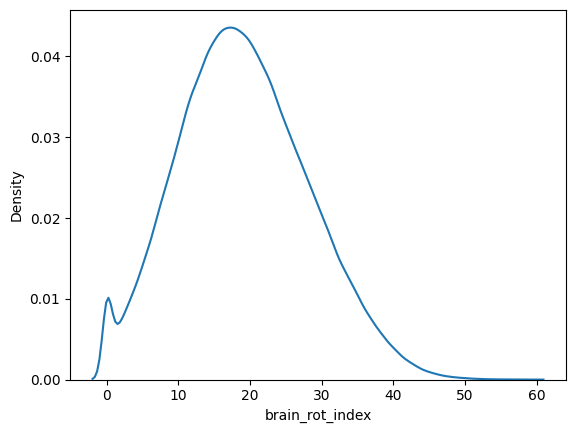

In [849]:
sns.kdeplot(data=working_df, x="brain_rot_index")

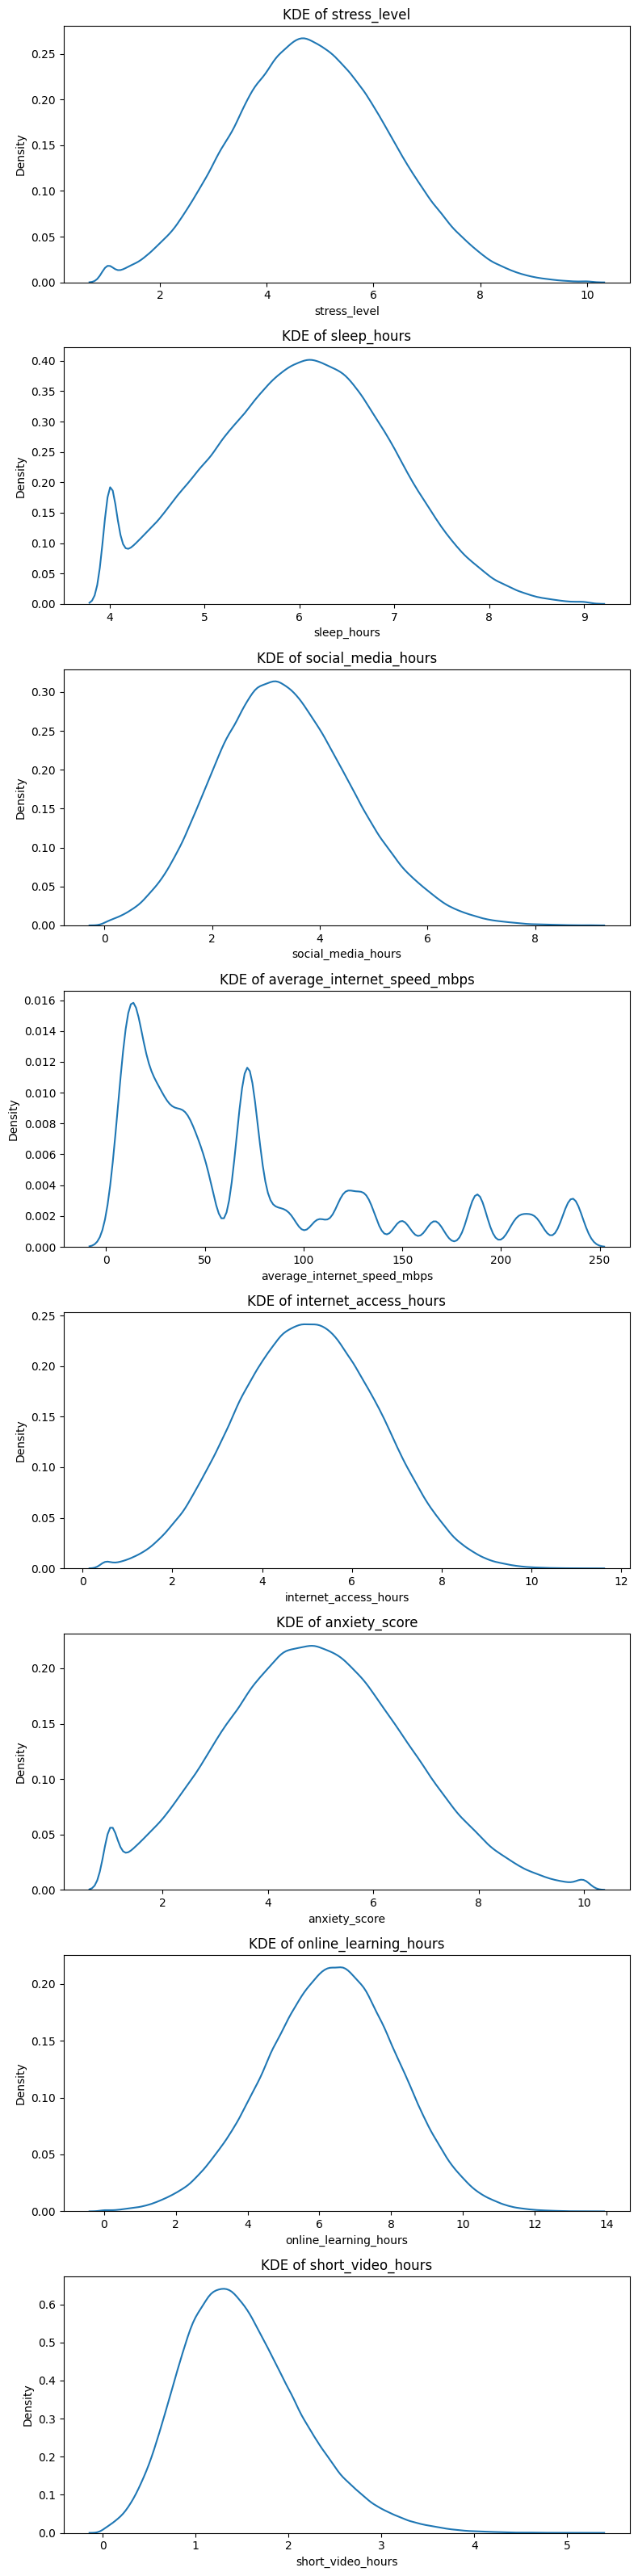

In [850]:
fig, axes = plt.subplots(len(skewed_list), 1, figsize=(8, 4 * len(skewed_list)))

if len(skewed_list) == 1:
    axes = [axes]

for i, col in enumerate(skewed_list):
    sns.kdeplot(data=numerical_df, x=col, ax=axes[i])
    axes[i].set_title(f"KDE of {col}")

plt.tight_layout()
plt.show()

In [851]:
normal_list

['student_id',
 'age',
 'sessions_per_day',
 'average_session_length_minutes',
 'likes_given_per_day',
 'comments_written_per_day',
 'posts_created_per_week',
 'brain_rot_index',
 'study_hours_per_week',
 'class_attendance_rate',
 'depression_score',
 'ads_viewed_per_day',
 'ads_clicked_per_week',
 'digital_spending_per_month']

In [852]:
for col in ['average_internet_speed_mbps', 'short_video_hours', 'social_media_hours' ]:
    working_df[col] = working_df[col].apply(lambda x: np.log(x + 0.001))

In [853]:
def get_outliers_percentage(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return len(df[(df[col] < lower_bound) | (df[col] > upper_bound)]) / len(df) * 100

In [854]:
def solve_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [855]:
outliers = {}
for column in working_df.select_dtypes(include=['int64', 'float64']).columns:
    outliers[column] = get_outliers_percentage(working_df, column)

outliers_df = pd.DataFrame(outliers, index=['percentage']).T
outliers_df = outliers_df[outliers_df['percentage'] > 0]
outliers_df.sort_values(by='percentage', ascending=True)

,percentage
sleep_hours,0.147823
stress_level,0.318080
anxiety_score,0.347324
internet_access_hours,0.349126
class_attendance_rate,0.362346
brain_rot_index,0.393193
study_hours_per_week,0.471311
online_learning_hours,0.599103
sessions_per_day,0.680827
average_session_length_minutes,0.689640


In [856]:
small_outliers_cols = outliers_df[outliers_df['percentage'] <= 1.5].index.tolist()
high_outliers_cols = outliers_df[outliers_df['percentage'] > 1.5].index.tolist()

In [857]:
new_df = working_df.copy()
for col in small_outliers_cols:
    new_df = solve_outliers(new_df, col)

# cap the rest
for col in high_outliers_cols:
    q1 = new_df[col].quantile(0.25)
    q3 = new_df[col].quantile(0.75)
    iqr = q3 - q1
    new_df.loc[new_df[col] > q3 + 1.5 * iqr, col] = q3 + 1.5 * iqr
    new_df.loc[new_df[col] < q1 - 1.5 * iqr, col] = q1 - 1.5 * iqr

In [858]:
working_df = new_df.copy()

In [859]:
working_df.drop(columns=['social_media_hours'], inplace=True)

## Key takeaways
- `age`, `sessions_per_day`, `average_session_length_minutes`, `likes_given_per_day`, `comments_written_per_day`, `posts_created_per_week`, `study_hours_per_week`, `class_attendance_rate`, `depression_score`, `ads_viewed_per_day`, `ads_clicked_per_week`, `digital_spending_per_month`  follows unifrom distribtion but needs standardization
- `average_internet_speed_mbps`, `education_content_hours`, `entertainment_content_hours`, `news_content_hours`, `short_video_hours`, `social_media_hours`    needs sqrt transformation followed by standardization

# Feature Engineering

## Feature Encoding

In [860]:
cat_df = working_df.select_dtypes(include=['object']).copy()

/var/folders/p6/82pzwvfj08b5bktj5wbwqwh00000gn/T/ipykernel_2822/840731593.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df = working_df.select_dtypes(include=['object']).copy()


In [861]:
cat_df.columns

Index(['development_level', 'gender', 'urban_rural', 'family_income_level',
       'device_access', 'education_level', 'late_night_usage',
       'cyberbullying_exposure', 'adult_content_exposure'],
      dtype='str')

In [862]:
def get_counts(df, col):
    print(df[col].value_counts())


In [863]:
get_counts(cat_df, 'device_access')

device_access
Smartphone       284732
Both              68832
Shared Device     63719
Laptop            51388
Name: count, dtype: int64


In [864]:
get_counts(cat_df, 'cyberbullying_exposure')

cyberbullying_exposure
No     412633
Yes     56038
Name: count, dtype: int64


In [865]:
get_counts(cat_df, 'gender')

gender
Female    230003
Male      229326
Other       9342
Name: count, dtype: int64


In [866]:
numerical_cols = working_df.drop(columns=['student_id', 'brain_rot_index']).select_dtypes(include=['int64', 'float64']).columns.tolist()

In [867]:
numerical_cols

['average_internet_speed_mbps',
 'age',
 'internet_access_hours',
 'online_learning_hours',
 'sessions_per_day',
 'average_session_length_minutes',
 'short_video_hours',
 'likes_given_per_day',
 'comments_written_per_day',
 'posts_created_per_week',
 'study_hours_per_week',
 'class_attendance_rate',
 'sleep_hours',
 'stress_level',
 'anxiety_score',
 'depression_score',
 'ads_viewed_per_day',
 'ads_clicked_per_week',
 'digital_spending_per_month']

In [868]:
working_df['gender'] = working_df['gender'].map({
    'Female': 0,
    'Male': 1,
    'Other': 2
})

working_df['urban_rural'] = working_df['urban_rural'].map({
    'Rural': 0,
    'Urban': 1
})

working_df['cyberbullying_exposure'] = working_df['cyberbullying_exposure'].map({
    'No': 0,
    'Yes': 1
})

working_df['adult_content_exposure'] = working_df['adult_content_exposure'].map({
    'No': 0,
    'Yes': 1
})

In [869]:
working_df['development_level'] = working_df['development_level'].map({
    'Developing': 2,
    'Developed': 1,
    'Underdeveloped': 0
})

working_df['family_income_level'] = working_df['family_income_level'].map({
    'High': 3,
    'Middle': 2,
    'Low': 1
})

working_df['education_level'] = working_df['education_level'].map({
    'PhD': 5,
    'Postgraduate': 4,
    'Graduate': 3,
    'Diploma': 2,
    'School': 1,
    'Dropout': 0
})

working_df['late_night_usage'] = working_df['late_night_usage'].map({
    'Never': 0,
    'Sometimes': 1,
    'Often': 2,
    'Always': 3
})

In [870]:
working_df.dropna(inplace=True)

In [871]:
working_df = pd.get_dummies(working_df, columns=['device_access'])

In [872]:
working_df.info()

<class 'pandas.DataFrame'>
Index: 468671 entries, 0 to 499999
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   student_id                      468671 non-null  int64  
 1   development_level               468671 non-null  int64  
 2   average_internet_speed_mbps     468671 non-null  float64
 3   age                             468671 non-null  int64  
 4   gender                          468671 non-null  int64  
 5   urban_rural                     468671 non-null  int64  
 6   family_income_level             468671 non-null  int64  
 7   internet_access_hours           468671 non-null  float64
 8   education_level                 468671 non-null  int64  
 9   online_learning_hours           468671 non-null  float64
 10  sessions_per_day                468671 non-null  float64
 11  average_session_length_minutes  468671 non-null  float64
 12  late_night_usage                

## Correlation Analysis

In [873]:
corr = working_df.corr(method='pearson')
vals = corr.values.copy()
np.fill_diagonal(vals, np.nan)
corr_no_diag = pd.DataFrame(vals, index=corr.index, columns=corr.columns)

most_corr = corr_no_diag.idxmax()
most_corr_values = corr_no_diag.max()

result = pd.DataFrame({
    'most_correlated_with': most_corr,
    'correlation': most_corr_values
})

In [874]:
result = result[result['correlation'] > 0.7].sort_values(by='correlation', ascending=False)

In [875]:
result

,most_correlated_with,correlation
sessions_per_day,ads_viewed_per_day,0.930041
ads_viewed_per_day,sessions_per_day,0.930041
average_session_length_minutes,ads_viewed_per_day,0.908874
ads_clicked_per_week,ads_viewed_per_day,0.873494
short_video_hours,ads_viewed_per_day,0.839957
stress_level,anxiety_score,0.815027
anxiety_score,stress_level,0.815027
family_income_level,digital_spending_per_month,0.779509
digital_spending_per_month,family_income_level,0.779509
likes_given_per_day,sessions_per_day,0.766210


In [876]:
working_df["ads_clicked_per_view"] = working_df["ads_clicked_per_week"] / (working_df["ads_viewed_per_day"] * 7)
working_df["stress_anxiety"] = working_df["stress_level"] + working_df["anxiety_score"]

In [877]:
working_df["likes_per_sessions"] = working_df["likes_given_per_day"] / working_df["sessions_per_day"]
working_df["comnent_per_sessions"] = working_df["comments_written_per_day"] / working_df["sessions_per_day"]
working_df["digital_spending_per_income_level"] = working_df["digital_spending_per_month"] / working_df["family_income_level"]

In [878]:
numerical_cols = list(set(numerical_cols + [
    "ads_clicked_per_view",
    "stress_anxiety",
    "likes_per_sessions",
    "comnent_per_sessions",
    "digital_spending_per_income_level"
]))

In [879]:
working_df.drop(columns=['short_video_hours', 'ads_viewed_per_day', 
                         'stress_level', 'anxiety_score', 'likes_given_per_day',
                         'comments_written_per_day', 'digital_spending_per_month'], inplace=True)

In [880]:
new_numeric = []
for col in numerical_cols:
    if col in working_df.columns.tolist():
        new_numeric.append(col)
numerical_cols = new_numeric

In [881]:
working_df.columns.tolist()

['student_id',
 'development_level',
 'average_internet_speed_mbps',
 'age',
 'gender',
 'urban_rural',
 'family_income_level',
 'internet_access_hours',
 'education_level',
 'online_learning_hours',
 'sessions_per_day',
 'average_session_length_minutes',
 'late_night_usage',
 'posts_created_per_week',
 'brain_rot_index',
 'study_hours_per_week',
 'class_attendance_rate',
 'sleep_hours',
 'depression_score',
 'ads_clicked_per_week',
 'cyberbullying_exposure',
 'adult_content_exposure',
 'device_access_Both',
 'device_access_Laptop',
 'device_access_Shared Device',
 'device_access_Smartphone',
 'ads_clicked_per_view',
 'stress_anxiety',
 'likes_per_sessions',
 'comnent_per_sessions',
 'digital_spending_per_income_level']

## Key takeaways
- drop `short_video_hours`, `ads_viewed_per_day` as they are highly correlated
- make a new column `likes_per_sessions` and drop `likes_given_per_day`
- make new column `digital_spending_per_income_level` = `digital_spending_per_month` / `family_income_level` and drop `family_income_level` 

## Feature Scaling

In [882]:
from sklearn.preprocessing import StandardScaler

In [883]:
scaler = StandardScaler()
working_df[numerical_cols] = scaler.fit_transform(working_df[numerical_cols])

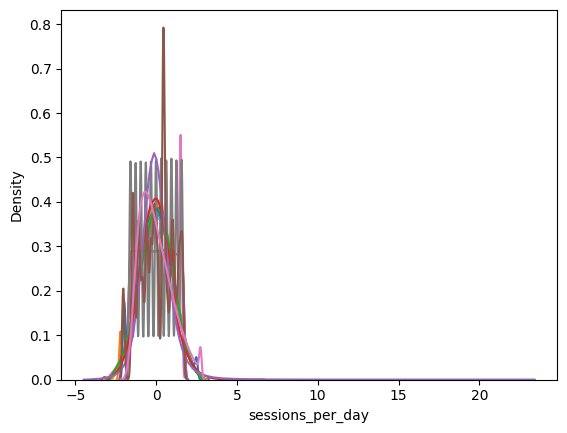

In [884]:
for col in numerical_cols:
    sns.kdeplot(data=working_df, x=col)

In [885]:
working_df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,468671.0,2.500211e+05,144382.891984,1.000000,124910.500000,250109.000000,375145.500000,500000.000000
development_level,468671.0,1.141639e+00,0.833119,0.000000,0.000000,1.000000,2.000000,2.000000
average_internet_speed_mbps,468671.0,-1.536699e-16,1.000001,-2.055348,-0.793223,0.006488,0.715653,1.649525
age,468671.0,8.659849e-17,1.000001,-1.586599,-0.953730,-0.004428,0.944875,1.577743
gender,468671.0,5.291772e-01,0.537601,0.000000,0.000000,1.000000,1.000000,2.000000
urban_rural,468671.0,5.497374e-01,0.497521,0.000000,0.000000,1.000000,1.000000,1.000000
family_income_level,468671.0,1.814409e+00,0.712459,1.000000,1.000000,2.000000,2.000000,3.000000
internet_access_hours,468671.0,-2.622212e-16,1.000001,-2.869304,-0.700453,0.002443,0.702401,2.967587
education_level,468671.0,1.745214e+00,1.131378,0.000000,1.000000,2.000000,3.000000,5.000000
online_learning_hours,468671.0,8.975194e-17,1.000001,-2.790782,-0.685071,0.015459,0.695605,2.808229


## Actions
- encode `gender` ```json {male : 1, female: 0}``` **Binary Encoding**
- encode `urban_rural` ```json{Urban: 1, Rural: 0}``` **Binary Encoding**
- encode `cyberbullying_exposure`, `adult_content_exposure` ```json {"No" : 0, "Yes": 1}``` **Binary Encoding**
- encode `development_level`, `family_income_level`, `education_level`, `late_night_usage` **Label encoding**
- encode `device_access` **One Hot Encoding**

# Baseline Model

In [886]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [887]:
X = working_df.drop(columns=['student_id', 'brain_rot_index']).values   
y = working_df['brain_rot_index'].values

In [888]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(root_mean_squared_error(y_test, y_pred))

6.734457103457522
